In [1]:
# Cell 1 — Setup and Load Everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
import sys

sys.path.append(os.path.abspath('..'))
from src.evaluate import sortino_ratio, sharpe_ratio, max_drawdown, total_return, cumulative_returns

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

# Load backtest results
results_df = pd.read_csv('../notebooks/backtest_results.csv', parse_dates=['date'])

# Load raw data
df       = pd.read_csv('../data/processed/iv_features.csv', parse_dates=['date'])
train_df = df[df['date'] <= '2023-12-31']
test_df  = df[df['date'] >= '2024-01-01'].reset_index(drop=True)

print(f'Backtest results: {len(results_df)} trading days')
print(f'Columns: {list(results_df.columns)}')
print(f'\nFirst 5 rows:')
results_df.head()

Backtest results: 250 trading days
Columns: ['date', 'action_requested', 'action_executed', 'override', 'daily_return', 'reward', 'portfolio_value']

First 5 rows:


,date,action_requested,action_executed,override,daily_return,reward,portfolio_value
0,2024-01-02,XLF,XLF,False,0.004246,0.004246,1.004255
1,2024-01-03,XLF,XLF,False,-0.008511,-0.008511,0.995744
2,2024-01-04,XLF,XLF,False,0.003999,0.003999,0.999734
3,2024-01-05,XLF,XLF,False,0.004247,0.004247,1.003989
4,2024-01-08,XLF,XLF,False,0.006338,0.006338,1.010372


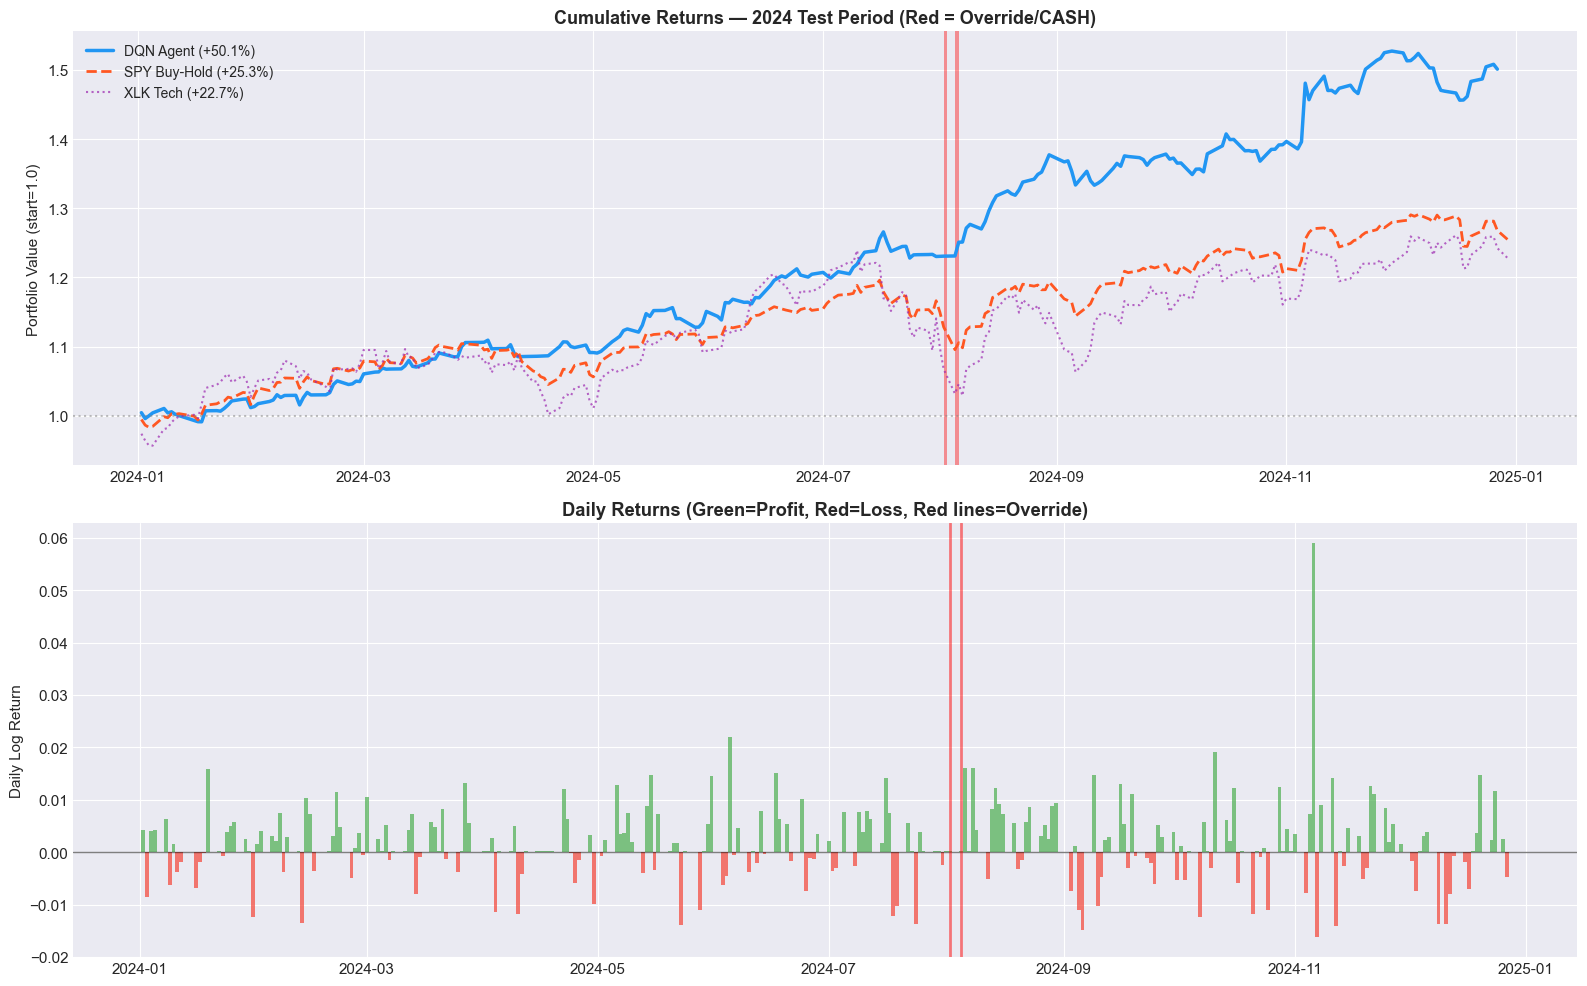

Positive days: 164 (65.6%)
Negative days: 85 (34.0%)
Best day:      +0.0590
Worst day:     -0.0163


In [2]:
# Cell 2 — Cumulative Returns + Daily Returns
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

ax1 = axes[0]

# Agent
ax1.plot(results_df['date'], results_df['portfolio_value'],
         label=f'DQN Agent (+{total_return(results_df["daily_return"].values):.1f}%)',
         color='#2196F3', linewidth=2.5)

# SPY
spy_rets = test_df['ret_spy'].dropna().values
spy_cum  = np.exp(np.cumsum(spy_rets))
ax1.plot(test_df.dropna(subset=['ret_spy'])['date'].values, spy_cum,
         label=f'SPY Buy-Hold (+{total_return(spy_rets):.1f}%)',
         color='#FF5722', linewidth=2, linestyle='--')

# XLK for reference
xlk_rets = test_df['ret_xlk'].dropna().values
xlk_cum  = np.exp(np.cumsum(xlk_rets))
ax1.plot(test_df.dropna(subset=['ret_xlk'])['date'].values, xlk_cum,
         label=f'XLK Tech ({total_return(xlk_rets):+.1f}%)',
         color='#9C27B0', linewidth=1.5, linestyle=':', alpha=0.7)

# Shade override periods
override_days = results_df[results_df['override']]['date']
for d in override_days:
    ax1.axvspan(d, d + pd.Timedelta(days=1), alpha=0.4, color='red', linewidth=0)

ax1.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
ax1.set_title('Cumulative Returns — 2024 Test Period (Red = Override/CASH)',
              fontweight='bold', fontsize=13)
ax1.set_ylabel('Portfolio Value (start=1.0)')
ax1.legend(fontsize=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Daily returns bar chart
ax2 = axes[1]
colors = ['#4CAF50' if r >= 0 else '#F44336'
          for r in results_df['daily_return']]
ax2.bar(results_df['date'], results_df['daily_return'],
        color=colors, alpha=0.7, width=1)
ax2.axhline(0, color='black', linewidth=1, alpha=0.5)
for d in override_days:
    ax2.axvline(d, color='red', alpha=0.5, linewidth=2)

ax2.set_title('Daily Returns (Green=Profit, Red=Loss, Red lines=Override)',
              fontweight='bold')
ax2.set_ylabel('Daily Log Return')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.savefig('../notebooks/returns_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

agent_rets = results_df['daily_return'].values
pos_days   = (agent_rets > 0).sum()
neg_days   = (agent_rets < 0).sum()
print(f'Positive days: {pos_days} ({pos_days/len(agent_rets)*100:.1f}%)')
print(f'Negative days: {neg_days} ({neg_days/len(agent_rets)*100:.1f}%)')
print(f'Best day:      {agent_rets.max():+.4f}')
print(f'Worst day:     {agent_rets.min():+.4f}')

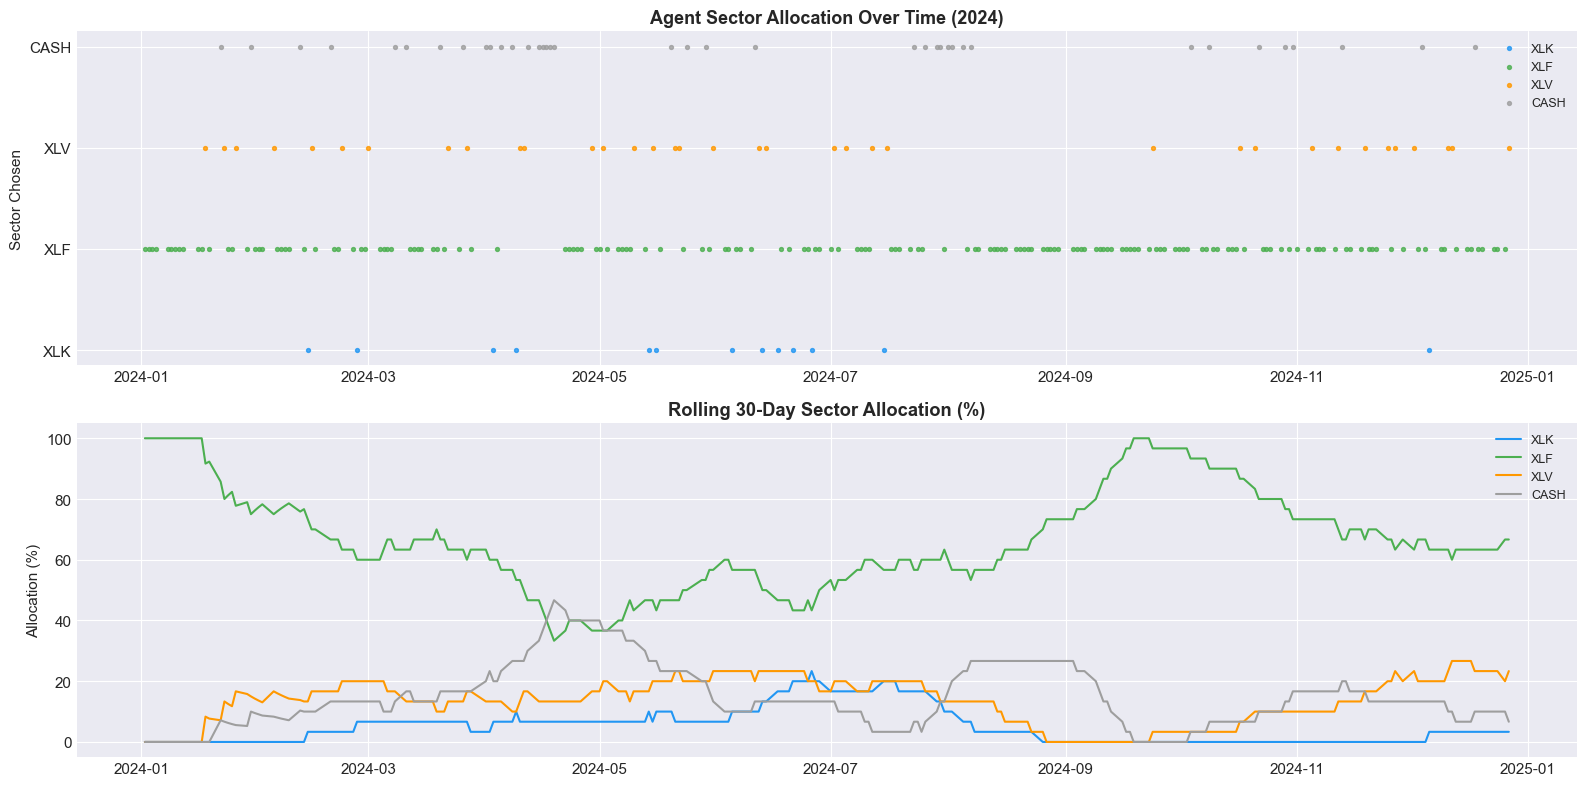

Sector allocation summary:
action_executed
XLF     163
CASH     38
XLV      36
XLK      13
Name: count, dtype: int64


In [3]:
# Cell 3 — Sector Allocation Over Time
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

action_color = {
    'XLK':  '#2196F3',
    'XLF':  '#4CAF50',
    'XLV':  '#FF9800',
    'CASH': '#9E9E9E'
}

ax1 = axes[0]
for action, color in action_color.items():
    mask = results_df['action_executed'] == action
    if mask.sum() > 0:
        ax1.scatter(results_df[mask]['date'],
                    [action] * mask.sum(),
                    c=color, s=8, alpha=0.8, label=action)

ax1.set_title('Agent Sector Allocation Over Time (2024)',
              fontweight='bold', fontsize=13)
ax1.set_ylabel('Sector Chosen')
ax1.legend(loc='upper right', fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

ax2 = axes[1]
window = 30
for action, color in action_color.items():
    rolling_pct = (results_df['action_executed'] == action).rolling(
        window, min_periods=1).mean() * 100
    ax2.plot(results_df['date'], rolling_pct,
             label=action, color=color, linewidth=1.5)

ax2.set_title(f'Rolling {window}-Day Sector Allocation (%)',
              fontweight='bold')
ax2.set_ylabel('Allocation (%)')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.savefig('../notebooks/sector_allocation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Sector allocation summary:')
print(results_df['action_executed'].value_counts())

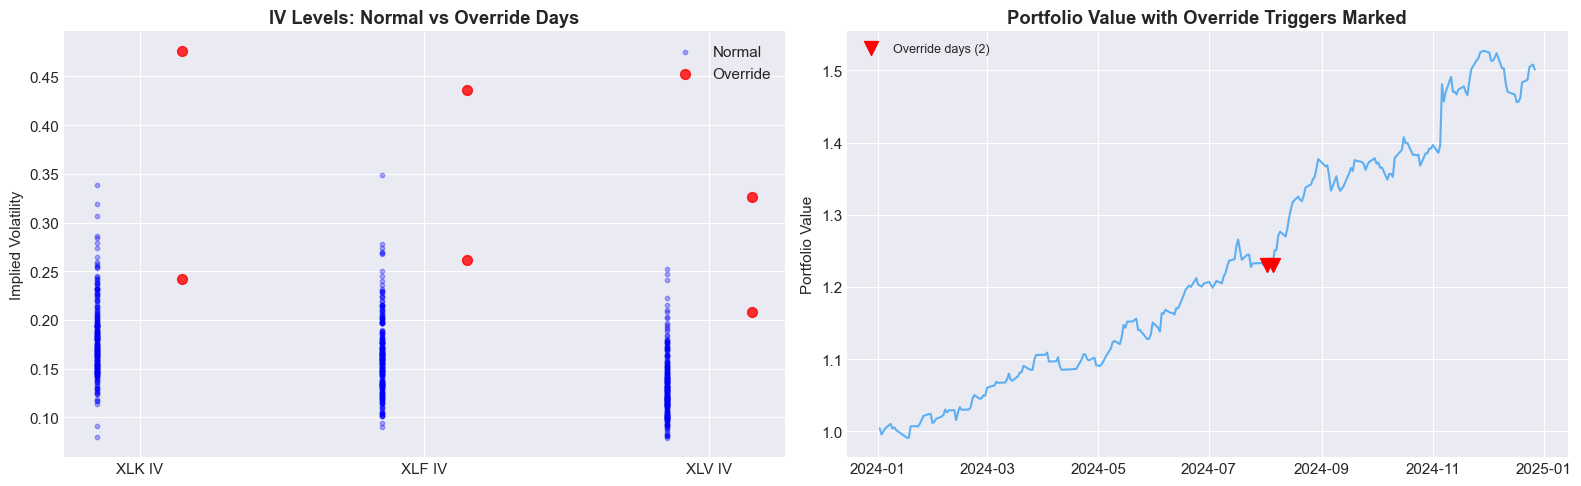

Override trigger dates in 2024:
  2024-08-02 | Return: +0.0002 | Portfolio: 1.2307
  2024-08-05 | Return: +0.0002 | Portfolio: 1.2309


In [4]:
# Cell 4 — Override Analysis Deep Dive
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

override_mask = results_df['override']
normal_mask   = ~override_mask

ax1 = axes[0]
ax1.set_title('IV Levels: Normal vs Override Days', fontweight='bold')
ax1.set_ylabel('Implied Volatility')

# Try to merge IV data with results
merged = results_df.merge(
    test_df[['date', 'iv_xlk', 'iv_xlf', 'iv_xlv']],
    on='date', how='left'
)

for i, (col, label) in enumerate([
    ('iv_xlk', 'XLK IV'),
    ('iv_xlf', 'XLF IV'),
    ('iv_xlv', 'XLV IV')
]):
    if col in merged.columns:
        normal_vals   = merged[~merged['override']][col].dropna()
        override_vals = merged[merged['override']][col].dropna()

        ax1.scatter([i - 0.15] * len(normal_vals), normal_vals,
                    alpha=0.3, color='blue', s=10,
                    label='Normal' if i == 0 else '')
        if len(override_vals) > 0:
            ax1.scatter([i + 0.15] * len(override_vals), override_vals,
                        alpha=0.8, color='red', s=50,
                        label='Override' if i == 0 else '')

ax1.set_xticks([0, 1, 2])
ax1.set_xticklabels(['XLK IV', 'XLF IV', 'XLV IV'])
ax1.legend()

ax2 = axes[1]
ax2.plot(results_df['date'], results_df['portfolio_value'],
         color='#2196F3', linewidth=1.5, alpha=0.7)

override_rows = results_df[results_df['override']]
if len(override_rows) > 0:
    ax2.scatter(override_rows['date'], override_rows['portfolio_value'],
                color='red', s=100, zorder=5,
                label=f'Override days ({len(override_rows)})',
                marker='v')

ax2.set_title('Portfolio Value with Override Triggers Marked', fontweight='bold')
ax2.set_ylabel('Portfolio Value')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.savefig('../notebooks/override_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Override trigger dates in 2024:')
if len(override_rows) > 0:
    for _, row in override_rows.iterrows():
        print(f"  {str(row['date'])[:10]} | "
              f"Return: {row['daily_return']:+.4f} | "
              f"Portfolio: {row['portfolio_value']:.4f}")
else:
    print('  No override triggers in 2024 test period')

In [5]:
# Cell 5 — Final Summary Table for Report
agent_rets = results_df['daily_return'].values
spy_rets   = test_df['ret_spy'].dropna().values

print('=' * 70)
print(f'{"FINAL RESULTS TABLE — FOR REPORT":^70}')
print('=' * 70)
print(f'{"Metric":<30} {"DQN Agent":>18} {"SPY Baseline":>18}')
print('-' * 70)

metrics = [
    ('Sortino Ratio (annualized)',
     sortino_ratio(agent_rets), sortino_ratio(spy_rets)),
    ('Sharpe Ratio (annualized)',
     sharpe_ratio(agent_rets), sharpe_ratio(spy_rets)),
    ('Total Return (%)',
     total_return(agent_rets), total_return(spy_rets)),
    ('Max Drawdown (%)',
     max_drawdown(agent_rets)*100, max_drawdown(spy_rets)*100),
    ('Positive Days (%)',
     (agent_rets > 0).mean()*100, (spy_rets > 0).mean()*100),
    ('Best Single Day (%)',
     agent_rets.max()*100, spy_rets.max()*100),
    ('Worst Single Day (%)',
     agent_rets.min()*100, spy_rets.min()*100),
    ('Volatility (ann. %)',
     agent_rets.std()*np.sqrt(252)*100,
     spy_rets.std()*np.sqrt(252)*100),
]

for label, agent_val, spy_val in metrics:
    better = '←' if agent_val > spy_val else ''
    if label == 'Max Drawdown (%)' or label == 'Worst Single Day (%)':
        better = '←' if agent_val > spy_val else ''  # less negative is better
    print(f'{label:<30} {agent_val:>18.4f} {spy_val:>18.4f} {better}')

print('=' * 70)
print(f'\nKey findings:')
print(f'1. Agent {sortino_ratio(agent_rets)/sortino_ratio(spy_rets):.1f}x '
      f'better Sortino than SPY')
print(f'2. Agent earns {total_return(agent_rets)/total_return(spy_rets):.1f}x '
      f'more return than SPY')
print(f'3. Agent max drawdown '
      f'{abs(max_drawdown(agent_rets)/max_drawdown(spy_rets))*100:.0f}% '
      f'of SPY drawdown (much smaller)')

                   FINAL RESULTS TABLE — FOR REPORT                   
Metric                                  DQN Agent       SPY Baseline
----------------------------------------------------------------------
Sortino Ratio (annualized)                 5.8385             2.3420 ←
Sharpe Ratio (annualized)                  3.3405             1.8032 ←
Total Return (%)                          50.1203            25.3425 ←
Max Drawdown (%)                          -4.6523            -8.4056 ←
Positive Days (%)                         65.6000            58.9641 ←
Best Single Day (%)                        5.9024             2.4561 ←
Worst Single Day (%)                      -1.6277            -3.0257 ←
Volatility (ann. %)                       12.2592            12.5768 

Key findings:
1. Agent 2.5x better Sortino than SPY
2. Agent earns 2.0x more return than SPY
3. Agent max drawdown 55% of SPY drawdown (much smaller)
